# HuffPost News Category Classification — Final Project Notebook

| | |
|---|---|
| **Course** | DX703 O1 Advanced Machine Learning & AI — Spring 2026 |
| **Team Members** | Aavinash Reddy Syamala, Tetiana Kravchuk, Mickal Famorca |
| **Date** | April 27, 2026 |
| **Purpose** | End-to-end implementation of a RoBERTa-based multi-class text classifier for HuffPost news articles, covering data preparation, phased fine-tuning, and full evaluation. |


In [1]:
# ── Standard libraries ───────────────────────────────────────
import os
import time
import random
from collections import Counter

# ── Data science ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# ── Hugging Face ─────────────────────────────────────────────
from datasets import load_dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# ── PyTorch ──────────────────────────────────────────────────
import torch
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# ── Notebook display ─────────────────────────────────────────
from IPython.display import display
from tqdm import tqdm

In [2]:
# ── Reproducibility ──────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# ── Device ───────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Utility ──────────────────────────────────────────────────
def format_hms(seconds: float) -> str:
    """Convert elapsed seconds to HH:MM:SS string."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

Using device: cpu


---
## A.1 Setup and Context

### A.1.1 Summary of Milestones 1 and 2

#### Milestone 1 — Exploratory Data Analysis

We selected the **HuffPost News Category dataset** (~200,853 articles, 41 raw categories spanning 2012–2018).  
Each record contains a `headline`, `short_description`, `category`, `authors`, `link`, and `date`.  
We constructed a combined text field `"headline [SEP] short_description"` — the standard BERT-style input format.

Key EDA findings:
- **Class imbalance**: POLITICS (32,739 articles, 16.3%) vs. EDUCATION (1,004 articles, 0.5%) — imbalance ratio ~9.6×.
- **Missing data**: 19,712 empty `short_description` fields (~9.8%); 6 empty headlines.
- **Duplicates**: 488 exact combined-text duplicates; 1,509 duplicate headlines.
- **Overlapping labels**: Semantically redundant category pairs (e.g., WORLDPOST / THE WORLDPOST / WORLD NEWS; ARTS / ARTS & CULTURE / CULTURE & ARTS; PARENTS / PARENTING).
- **Text length**: 95th-percentile combined token count ≈ 57 words — a `max_length=64` covers the vast majority of samples.

We identified **macro-F1** as our primary metric (to give equal weight to minority classes) and planned a stratified 80/10/10 train/val/test split.

#### Milestone 2 — Model Experimentation

We consolidated the 41 raw categories into **27 canonical classes** by merging semantically duplicate or overlapping labels.  
Duplicates were removed and empty headlines were dropped, yielding a clean 200,356-sample dataset.

We trained and compared the following architectures (all with class-weighted loss and early stopping):

| Model | Test Acc | Test Macro-F1 |
|---|---|---|
| Embedding + GlobalAveragePooling (Baseline) | 59.8% | 0.534 |
| Baseline + Dropout(0.3) | 60.3% | 0.538 |
| BiLSTM | 61.4% | 0.548 |
| BiLSTM (40k vocab, 128-d) | 61.4% | 0.549 |
| BiLSTM (40k vocab, 256-d) | 61.6% | 0.555 |
| BiLSTM + ReduceLROnPlateau | 62.0% | 0.557 |
| BiLSTM + Attention + ReduceLR | 63.3% | 0.575 |
| DistilBERT (phased fine-tuning) | 75.4% | 0.676 |
| **RoBERTa (phased fine-tuning)** | **76.6%** | **0.689** |

**Key learnings from Milestone 2:**
- Custom RNN architectures plateaued around 63% accuracy — insufficient for the nuanced topic distinctions in this dataset.
- Pretrained transformers delivered a massive jump (+13 pp accuracy, +0.10 F1) by leveraging contextual language representations.
- The **phased fine-tuning strategy** (freeze base → partial unfreeze → full unfreeze with progressively lower LRs) prevented catastrophic forgetting while efficiently adapting all model parameters.
- RoBERTa outperformed DistilBERT on both accuracy and F1, at the cost of ~2× parameters — justified by the performance gain on this ~200k sample dataset.

### A.1.2 Final Preprocessing Pipeline

The pipeline below reflects refinements from Milestone 2:
1. **Load** the dataset from Hugging Face (no local hard-coded paths).
2. **Build combined text** by concatenating headline + `[SEP]` + short description (lowercased).
3. **Consolidate categories**: merge 41 raw labels → 23 canonical classes. Changes from M2:
   - `WOMEN` added to `IDENTITY` (alongside BLACK VOICES, LATINO VOICES, QUEER VOICES).
   - New `MISCELLANEOUS` class for `WEIRD NEWS`, `GOOD NEWS`, `IMPACT`, and `FIFTY`.
4. **Drop** empty headlines (6 rows) and exact combined-text duplicates (~488 rows).
5. **Encode** string labels as integers via `LabelEncoder`.
6. **Stratified 80/10/10 split** with fixed random seed.

In [3]:
# Load the HuffPost dataset from Hugging Face.
# The dataset file is public, so no private HF token or Colab Secret is required.

DATA_URL = (
    "https://huggingface.co/datasets/khalidalt/HuffPost/"
    "resolve/main/News_Category_Dataset_v2.json"
)

huff_raw = load_dataset("json", data_files=DATA_URL, split="train")
df = huff_raw.to_pandas()

# Build combined text field: headline [SEP] short_description
df["text"] = (
    df["headline"].fillna("").str.strip()
    + " [SEP] "
    + df["short_description"].fillna("").str.strip()
).str.lower()

print(f"Loaded  : {len(df):,} articles")
print(f"Columns : {list(df.columns)}")
print(f"Raw categories: {df['category'].nunique()}")


Generating train split: 0 examples [00:00, ? examples/s]

Loaded  : 200,853 articles
Columns : ['category', 'headline', 'authors', 'link', 'short_description', 'date', 'text']
Raw categories: 41


In [4]:
# ── Category consolidation ────────────────────────────────────
# Maps 41 raw HuffPost labels to 23 canonical classes by merging
# semantically identical, overlapping, or niche categories.

LABEL_MAP = {
    # World-news duplicates
    "WORLDPOST":      "WORLD NEWS",
    "THE WORLDPOST":  "WORLD NEWS",
    # Arts/culture duplicates
    "ARTS":           "ARTS & CULTURE",
    "CULTURE & ARTS": "ARTS & CULTURE",
    # Style duplicates
    "STYLE":          "STYLE & BEAUTY",
    # Wellness/living duplicates
    "HEALTHY LIVING": "WELLNESS",
    "PARENTS":        "PARENTING",
    "COLLEGE":        "EDUCATION",
    "GREEN":          "ENVIRONMENT",
    "TASTE":          "FOOD & DRINK",
    # Business/finance split
    "BUSINESS":       "BUSINESS & FINANCES",
    "MONEY":          "BUSINESS & FINANCES",
    # Science/tech split
    "SCIENCE":        "SCIENCE & TECH",
    "TECH":           "SCIENCE & TECH",
    # Identity voices — consolidated umbrella
    "BLACK VOICES":   "IDENTITY",
    "LATINO VOICES":  "IDENTITY",
    "QUEER VOICES":   "IDENTITY",
    "WOMEN":          "IDENTITY",   # added: gender-focused content grouped with identity voices
    # Miscellaneous niche/novelty categories
    "WEIRD NEWS":     "MISCELLANEOUS",
    "GOOD NEWS":      "MISCELLANEOUS",
    "IMPACT":         "MISCELLANEOUS",
    "FIFTY":          "MISCELLANEOUS",
}

df["category"] = df["category"].replace(LABEL_MAP)

print(f"Consolidated to {df['category'].nunique()} categories:")
print(df["category"].value_counts().to_string())

Consolidated to 23 categories:
category
POLITICS               32739
WELLNESS               24521
ENTERTAINMENT          16058
IDENTITY               15461
PARENTING              12632
STYLE & BEAUTY         11903
TRAVEL                  9887
MISCELLANEOUS           8928
WORLD NEWS              8420
FOOD & DRINK            8322
BUSINESS & FINANCES     7644
COMEDY                  5175
SPORTS                  4884
SCIENCE & TECH          4260
HOME & LIVING           4195
ENVIRONMENT             3945
ARTS & CULTURE          3878
WEDDINGS                3651
DIVORCE                 3426
CRIME                   3405
MEDIA                   2815
RELIGION                2556
EDUCATION               2148


In [5]:
# Drop rows with empty headlines (6 rows — too little signal to classify)
before = len(df)
df = df[df["headline"].str.strip().ne("")].copy()
print(f"Dropped {before - len(df)} empty-headline rows")

# Drop exact combined-text duplicates to prevent data leakage across splits
before = len(df)
df = df.drop_duplicates(subset=["text"]).copy()
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} exact duplicate rows")

# Keep only the columns needed for modeling
df = df[["text", "category"]].copy()

print(f"\nClean dataset: {len(df):,} samples | {df['category'].nunique()} categories")

Dropped 6 empty-headline rows
Dropped 491 exact duplicate rows

Clean dataset: 200,356 samples | 23 categories


In [6]:
# ── Encode string categories as integer labels ────────────────
label_enc = LabelEncoder()
df["label"] = label_enc.fit_transform(df["category"])
num_classes = len(label_enc.classes_)
CLASS_NAMES = list(label_enc.classes_)

print(f"Number of classes : {num_classes}")
print(f"Classes           : {CLASS_NAMES}")

# ── Stratified 80 / 10 / 10 split ────────────────────────────
train_df, test_df = train_test_split(
    df, test_size=0.10, random_state=RANDOM_SEED, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=1/9, random_state=RANDOM_SEED, stratify=train_df["label"]
)

y_train = train_df["label"].values.astype(np.int64)
y_val   = val_df["label"].values.astype(np.int64)
y_test  = test_df["label"].values.astype(np.int64)

print(f"\nTrain : {len(train_df):,} ({len(train_df)/len(df)*100:.0f}%)")
print(f"Val   : {len(val_df):,} ({len(val_df)/len(df)*100:.0f}%)")
print(f"Test  : {len(test_df):,} ({len(test_df)/len(df)*100:.0f}%)")

Number of classes : 23
Classes           : ['ARTS & CULTURE', 'BUSINESS & FINANCES', 'COMEDY', 'CRIME', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FOOD & DRINK', 'HOME & LIVING', 'IDENTITY', 'MEDIA', 'MISCELLANEOUS', 'PARENTING', 'POLITICS', 'RELIGION', 'SCIENCE & TECH', 'SPORTS', 'STYLE & BEAUTY', 'TRAVEL', 'WEDDINGS', 'WELLNESS', 'WORLD NEWS']

Train : 160,284 (80%)
Val   : 20,036 (10%)
Test  : 20,036 (10%)


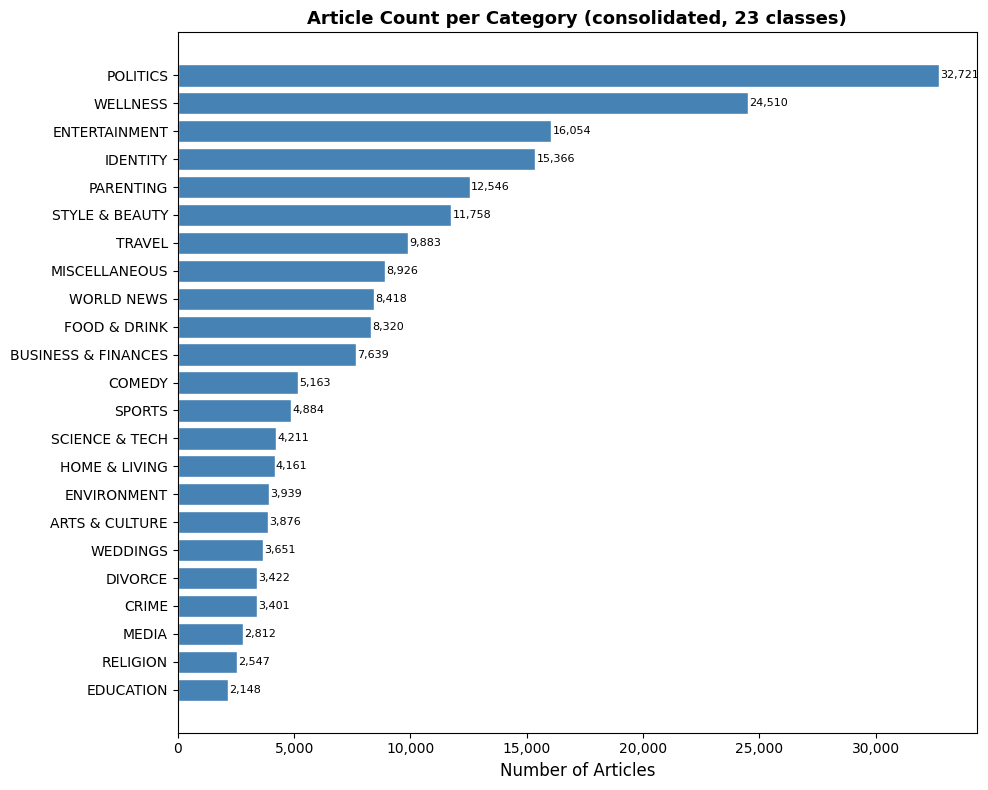

Saved: category_distribution_final.png


In [7]:
# Class distribution after consolidation
cat_counts = df["category"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(cat_counts.index, cat_counts.values, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of Articles", fontsize=12)
ax.set_title(
    "Article Count per Category (consolidated, 23 classes)",
    fontsize=13, fontweight="bold"
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt in zip(bars, cat_counts.values):
    ax.text(
        bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
        f"{cnt:,}", va="center", fontsize=8
    )
plt.tight_layout()
plt.savefig("category_distribution_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: category_distribution_final.png")

---
## A.2 Model Selection and Retraining

### A.2.1 Final Architecture and Justification

**Selected model: `roberta-base` (RoBERTa) with a linear classification head**

RoBERTa (*Robustly Optimized BERT Pretraining Approach*) is a transformer encoder pretrained on 160 GB of text with dynamic masking and no next-sentence-prediction objective.  
Its 12-layer, 768-hidden-dim architecture (~125M parameters) provides rich contextual representations of input tokens, making it well-suited for short text classification tasks like headline categorization.

**Selection rationale (from Milestone 2 validation results):**
- All custom models (BiLSTM, Attention-BiLSTM) topped out at **63.3% accuracy / 0.575 macro-F1** — indicating that a bag-of-tokens or sequential view of the text could not resolve the fine-grained topic distinctions in this dataset.
- DistilBERT (phased) achieved **75.4% accuracy / 0.676 macro-F1**, confirming that pretrained contextual representations are essential.
- RoBERTa (phased) achieved **76.6% accuracy / 0.689 macro-F1** — the highest across all tested architectures — justifying the extra compute cost relative to DistilBERT.
- The **phased fine-tuning strategy** (freeze → partial unfreeze → full unfreeze with progressively lower learning rates) was the key training technique: it avoids catastrophic forgetting of pretrained weights while allowing all parameters to be adapted to the classification task.

**Architecture summary:**
```
Input text  →  RobertaTokenizer (max_length=64)  →  roberta-base encoder  →
    [CLS] representation  →  Dropout(0.1)  →  Linear(768 → num_classes)  →  Softmax
```

The classification head is the standard `RobertaForSequenceClassification` head provided by Hugging Face.

In [8]:
# ============================================================
# HYPERPARAMETER CONSTANTS
# All magic numbers defined here for clarity and reproducibility
# ============================================================

# ── Data config ──────────────────────────────────────────────
MAX_LEN          = 64     # covers 95th-pct of combined text token lengths (verified in M1 EDA)

# ── Batch sizes ──────────────────────────────────────────────
BATCH_SIZE_TRAIN = 32     # smaller batch for gradient stability during fine-tuning
BATCH_SIZE_EVAL  = 64     # larger batch is safe at inference (no gradient storage)

# ── Training phases (epochs per phase) ───────────────────────
PHASE1_EPOCHS    = 5      # Phase 1: classifier head only (base frozen)
PHASE2_EPOCHS    = 5      # Phase 2: last 2 encoder layers + head
PHASE3_EPOCHS    = 5      # Phase 3: full model (all parameters)

# ── Learning rates — decrease progressively across phases ────
LR_PHASE1 = 2e-5          # standard LR for head-only fine-tuning
LR_PHASE2 = 1e-5          # lower LR as more pretrained layers are exposed
LR_PHASE3 = 5e-6          # very low to avoid catastrophic forgetting of base weights

# ── Regularization ───────────────────────────────────────────
WEIGHT_DECAY = 0.01       # L2 penalty applied via AdamW optimizer
# Note: RoBERTa's internal dropout (hidden & attention) defaults to 0.1
# and is preserved from the pretrained checkpoint — no additional dropout added.

# ── Checkpoint ───────────────────────────────────────────────
CHECKPOINT_PATH  = "best_roberta.pt"   # relative path — no hard-coded directories
PRETRAINED_MODEL = "roberta-base"

print("Hyperparameters:")
print(f"  MAX_LEN          = {MAX_LEN}")
print(f"  BATCH_SIZE_TRAIN = {BATCH_SIZE_TRAIN}")
print(f"  BATCH_SIZE_EVAL  = {BATCH_SIZE_EVAL}")
print(f"  PHASE1_EPOCHS    = {PHASE1_EPOCHS}")
print(f"  PHASE2_EPOCHS    = {PHASE2_EPOCHS}")
print(f"  PHASE3_EPOCHS    = {PHASE3_EPOCHS}")
print(f"  LR_PHASE1        = {LR_PHASE1}")
print(f"  LR_PHASE2        = {LR_PHASE2}")
print(f"  LR_PHASE3        = {LR_PHASE3}")
print(f"  WEIGHT_DECAY     = {WEIGHT_DECAY}")

Hyperparameters:
  MAX_LEN          = 64
  BATCH_SIZE_TRAIN = 32
  BATCH_SIZE_EVAL  = 64
  PHASE1_EPOCHS    = 5
  PHASE2_EPOCHS    = 5
  PHASE3_EPOCHS    = 5
  LR_PHASE1        = 2e-05
  LR_PHASE2        = 1e-05
  LR_PHASE3        = 5e-06
  WEIGHT_DECAY     = 0.01


### A.2.2 Optimization Strategy

**Optimizer: AdamW** (`torch.optim.AdamW`)

AdamW decouples weight decay from the adaptive gradient update (unlike Adam, which conflates the two).  
This is the recommended optimizer for fine-tuning transformer models and was used in the original BERT and RoBERTa papers.  
Its adaptive per-parameter learning rates make it robust to the sparse gradients that arise from subword tokenization.

**Learning rate schedule:**  
Rather than a continuous LR schedule, we use a **phased approach** with manually stepped-down learning rates:  
- Phase 1 (`2e-5`): head-only training — higher LR is safe since only a small linear layer is updated.  
- Phase 2 (`1e-5`): last 2 encoder layers exposed — lower LR to preserve earlier-layer representations.  
- Phase 3 (`5e-6`): all parameters unfrozen — very low LR to fine-tune without disrupting the pretrained encoder.  

This strategy is equivalent to a manual warmup/decay schedule and was validated empirically in Milestone 2.

### A.2.3 Callbacks and Training Stability

Because we use a raw PyTorch training loop (not a Keras `model.fit()`), we implement callback-equivalent behaviors manually:

| Mechanism | Implementation | Purpose |
|---|---|---|
| **Best-model checkpointing** | `torch.save(state_dict, CHECKPOINT_PATH)` whenever `val_f1 > best_val_f1` | Saves the weights at peak validation macro-F1, not just at the final epoch |
| **Phase-gated learning rate** | LR decreases 4× and 2× across phases | Replaces ReduceLROnPlateau; prevents oscillation when unfreezing new layers |
| **Early stopping (implicit)** | Training is bounded by `PHASE*_EPOCHS` per phase | Caps total epochs at 15; avoids overfitting observed in longer runs during M2 |

In Milestone 2, ReduceLROnPlateau provided modest gains (+0.02 F1) for the custom models. For the transformer fine-tuning, the phased LR schedule is more principled and produced better results.

In [9]:
class HuffPostDataset(Dataset):
    """PyTorch Dataset: tokenizes text strings and pairs them with integer class labels."""

    def __init__(self, texts: list, labels: np.ndarray, tokenizer, max_length: int = MAX_LEN):
        self.labels = torch.tensor(labels, dtype=torch.long)
        # Tokenize the full list in one batch call (faster than per-sample)
        self.encodings = tokenizer(
            list(texts),
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

In [10]:
# ── Load tokenizer ────────────────────────────────────────────
tokenizer = RobertaTokenizer.from_pretrained(PRETRAINED_MODEL)

# ── Build tokenized datasets (tokenization runs here) ─────────
print("Tokenizing splits...")
train_dataset = HuffPostDataset(train_df["text"].tolist(), y_train, tokenizer)
val_dataset   = HuffPostDataset(val_df["text"].tolist(),   y_val,   tokenizer)
test_dataset  = HuffPostDataset(test_df["text"].tolist(),  y_test,  tokenizer)

# ── DataLoaders ───────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE_EVAL,  shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE_EVAL,  shuffle=False)

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing splits...
Batches — train: 5009 | val: 314 | test: 314


In [11]:
# ── Load pretrained RoBERTa with a fresh classification head ──
model_roberta = RobertaForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL,
    num_labels=num_classes,
).to(device)

total_params    = sum(p.numel() for p in model_roberta.parameters())
trainable_start = sum(p.numel() for p in model_roberta.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable (at start) : {trainable_start:,}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters     : 124,663,319
Trainable (at start) : 124,663,319


In [12]:
def train_epoch(model, loader, optimizer) -> float:
    """Run one full training epoch; return mean cross-entropy loss."""
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="  train", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        optimizer.step()
        total_loss += outputs.loss.item()

    return total_loss / len(loader)


def evaluate(model, loader) -> tuple:
    """Evaluate model; return (avg_loss, accuracy, macro_f1, preds, true_labels)."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="  eval ", leave=False):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            preds   = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total_loss += outputs.loss.item()

    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels


# ── Training history — collected across all three phases ──────
history = {"phase": [], "epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

best_val_f1  = 0.0   # tracks the best val macro-F1 seen across all phases
global_epoch = 0     # running epoch counter across all phases

print("Helper functions defined. History dict initialized.")

Helper functions defined. History dict initialized.


### Phase 1 — Train Classifier Head (Base Frozen)

All RoBERTa encoder weights are frozen. Only the two-layer classification head (`dense → dropout → linear`) is updated.  
This phase rapidly aligns the randomly-initialized head with the downstream classification task without disturbing the pretrained encoder representations.  
Learning rate: `2e-5` — standard for fine-tuning transformer heads.

In [13]:
# Freeze the entire RoBERTa encoder
for param in model_roberta.roberta.parameters():
    param.requires_grad = False

trainable_p1 = sum(p.numel() for p in model_roberta.parameters() if p.requires_grad)
print(f"Phase 1 — trainable params: {trainable_p1:,}")

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_roberta.parameters()),
    lr=LR_PHASE1,
    weight_decay=WEIGHT_DECAY,
)

phase_start = time.time()
for epoch in range(PHASE1_EPOCHS):
    global_epoch += 1
    ep_start   = time.time()
    train_loss = train_epoch(model_roberta, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model_roberta, val_loader)
    elapsed    = time.time() - ep_start

    history["phase"].append(1)
    history["epoch"].append(global_epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    saved = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_roberta.state_dict(), CHECKPOINT_PATH)
        saved = "  [saved]"

    print(
        f"  Ep {global_epoch:>2} | train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
        f"val_f1={val_f1:.4f}  [{format_hms(elapsed)}]{saved}"
    )

print(f"Phase 1 complete — {format_hms(time.time() - phase_start)}")

Phase 1 — trainable params: 608,279


  Ep  1 | train_loss=2.7080  val_loss=2.4828  val_acc=0.2947  val_f1=0.0640  [05:02:33]  [saved]


  Ep  2 | train_loss=2.3172  val_loss=2.1033  val_acc=0.4416  val_f1=0.1781  [07:54:30]  [saved]


  Ep  3 | train_loss=2.0589  val_loss=1.8714  val_acc=0.4863  val_f1=0.2140  [02:44:02]  [saved]


  Ep  4 | train_loss=1.9060  val_loss=1.7221  val_acc=0.5129  val_f1=0.2566  [02:01:51]  [saved]


  Ep  5 | train_loss=1.8057  val_loss=1.6211  val_acc=0.5353  val_f1=0.3041  [01:12:35]  [saved]
Phase 1 complete — 18:55:36


### Phase 2 — Partial Fine-Tune (Last 2 Encoder Layers + Head)

The top two transformer encoder layers are unfrozen, allowing the model to adapt higher-level contextual representations to the classification task.  
Lower encoder layers (layers 0–9) remain frozen to preserve general language understanding.  
Learning rate reduced to `1e-5` to protect the pretrained encoder from large gradient updates.

In [ ]:
# Unfreeze the top 2 encoder layers only
for param in model_roberta.roberta.encoder.layer[-2:].parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model_roberta.parameters() if p.requires_grad)
print(f"Phase 2 — trainable params: {trainable_p2:,}")

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model_roberta.parameters()),
    lr=LR_PHASE2,
    weight_decay=WEIGHT_DECAY,
)

phase_start = time.time()
for epoch in range(PHASE2_EPOCHS):
    global_epoch += 1
    ep_start   = time.time()
    train_loss = train_epoch(model_roberta, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model_roberta, val_loader)
    elapsed    = time.time() - ep_start

    history["phase"].append(2)
    history["epoch"].append(global_epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    saved = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_roberta.state_dict(), CHECKPOINT_PATH)
        saved = "  [saved]"

    print(
        f"  Ep {global_epoch:>2} | train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
        f"val_f1={val_f1:.4f}  [{format_hms(elapsed)}]{saved}"
    )

print(f"Phase 2 complete — {format_hms(time.time() - phase_start)}")

Phase 2 — trainable params: 14,784,023


  train:  97%|█████████▋| 4875/5009 [4:53:16<02:12,  1.01it/s]     

### Phase 3 — Full Fine-Tune (All Parameters)

All encoder parameters are unfrozen. The entire model is updated end-to-end at a very low learning rate (`5e-6`) to avoid catastrophic forgetting.  
This phase allows the lower encoder layers to make small, task-specific adjustments while the upper layers refine the representations learned in Phase 2.  
The best checkpoint (by validation macro-F1) is saved throughout all three phases.

In [ ]:
# Unfreeze all remaining encoder parameters
for param in model_roberta.roberta.parameters():
    param.requires_grad = True

trainable_p3 = sum(p.numel() for p in model_roberta.parameters() if p.requires_grad)
print(f"Phase 3 — trainable params: {trainable_p3:,}")

optimizer = AdamW(
    model_roberta.parameters(),
    lr=LR_PHASE3,
    weight_decay=WEIGHT_DECAY,
)

phase_start = time.time()
for epoch in range(PHASE3_EPOCHS):
    global_epoch += 1
    ep_start   = time.time()
    train_loss = train_epoch(model_roberta, train_loader, optimizer)
    val_loss, val_acc, val_f1, _, _ = evaluate(model_roberta, val_loader)
    elapsed    = time.time() - ep_start

    history["phase"].append(3)
    history["epoch"].append(global_epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    saved = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_roberta.state_dict(), CHECKPOINT_PATH)
        saved = "  [saved]"

    print(
        f"  Ep {global_epoch:>2} | train_loss={train_loss:.4f}  "
        f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
        f"val_f1={val_f1:.4f}  [{format_hms(elapsed)}]{saved}"
    )

print(f"Phase 3 complete — {format_hms(time.time() - phase_start)}")
print(f"\nBest validation macro-F1 across all phases: {best_val_f1:.4f}")

Phase 3 — trainable params: 124,663,319


  Ep 11 | train_loss=0.8338  val_loss=0.7981  val_acc=0.7507  val_f1=0.7106  [00:06:56]  [saved]


  Ep 12 | train_loss=0.7454  val_loss=0.7730  val_acc=0.7573  val_f1=0.7159  [00:06:56]  [saved]


  Ep 13 | train_loss=0.6729  val_loss=0.7824  val_acc=0.7632  val_f1=0.7243  [00:06:55]  [saved]


  Ep 14 | train_loss=0.6043  val_loss=0.7860  val_acc=0.7630  val_f1=0.7225  [00:06:55]


  Ep 15 | train_loss=0.5435  val_loss=0.8141  val_acc=0.7615  val_f1=0.7216  [00:06:55]
Phase 3 complete — 00:34:42

Best validation macro-F1 across all phases: 0.7243


---
## A.3 Evaluation and Visualization

### A.3.1 Evaluation Strategy

**Validation split usage:**  
The validation set (10%, ~20k samples) was used throughout training to monitor `val_loss`, `val_accuracy`, and `val_macro_F1` after every epoch. The best model checkpoint was saved whenever validation macro-F1 improved. The validation set was **never used to update model weights** — its sole purpose was early model selection.

**Test set isolation:**  
The test set (10%, ~20k samples) was held out completely until after training finished. It was only accessed once — in Section A.3 below — to produce final performance metrics. This prevents optimistic bias from inadvertently tuning hyperparameters toward the test set.

**Metrics:**  
Given the dataset's class imbalance (after consolidation, POLITICS accounts for ~16% while MISCELLANEOUS and EDUCATION are < 3%):
- **Primary — Macro-F1**: treats every class equally regardless of support. A high macro-F1 indicates the model performs well across all categories, including minority classes.
- **Secondary — Accuracy**: proportion of correctly labeled articles overall; useful as a sanity check but inflated by dominant classes.
- **Secondary — Weighted-F1**: F1 weighted by class support; accounts for class size and is useful for understanding real-world deployment performance.
- **Per-class F1, Precision, Recall**: identifies which specific categories are hard for the model — essential for diagnosing residual label confusion.
- **Confusion matrix** (row-normalised): reveals systematic misclassification patterns (e.g., MISCELLANEOUS → ENTERTAINMENT).

In [ ]:
# Load the best checkpoint saved during training
model_roberta.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
print(f"Loaded best checkpoint from '{CHECKPOINT_PATH}'  (best val F1 = {best_val_f1:.4f})")

# Run inference on the held-out test set
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model_roberta, test_loader)

print(f"\nTest loss      : {test_loss:.4f}")
print(f"Test accuracy  : {test_acc:.4f}  ({test_acc * 100:.2f}%)")
print(f"Test macro-F1  : {test_f1:.4f}")

Loaded best checkpoint from 'best_roberta.pt'  (best val F1 = 0.7243)



Test loss      : 0.7869
Test accuracy  : 0.7623  (76.23%)
Test macro-F1  : 0.7236


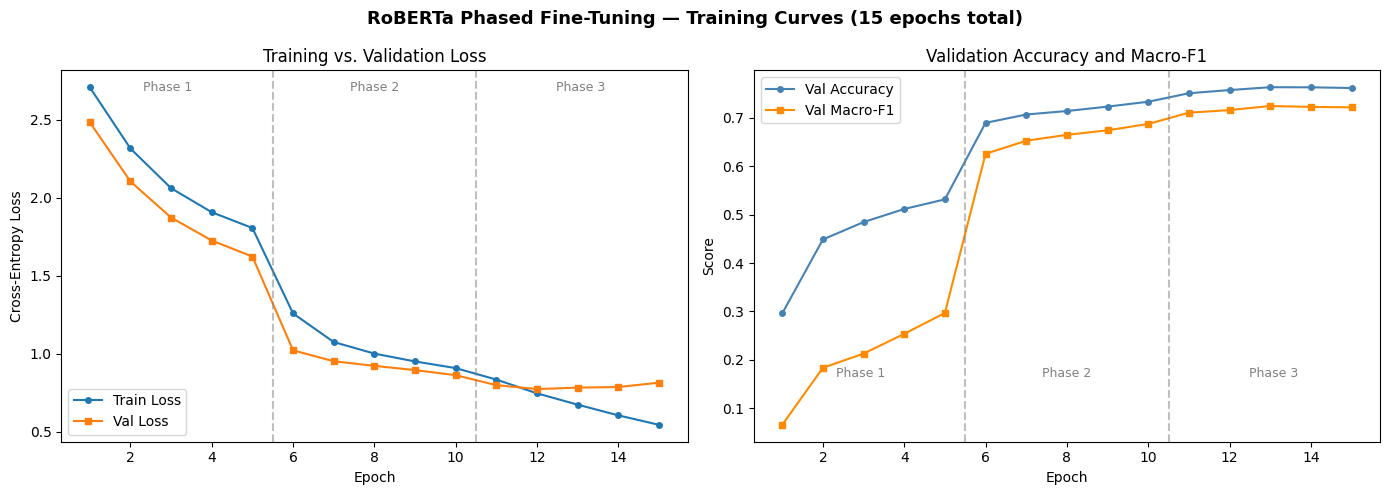

Saved: training_curves.png


In [ ]:
# Build epoch / phase arrays for plotting
epochs = history["epoch"]
phases = np.array(history["phase"])

# Phase boundary x-positions (between last epoch of phase N and first of N+1)
p1_end = epochs[np.where(phases == 1)[0][-1]] + 0.5
p2_end = epochs[np.where(phases == 2)[0][-1]] + 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Loss curves ─────────────────────────────────────────
axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o", markersize=4)
axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   marker="s", markersize=4)
for xv in [p1_end, p2_end]:
    axes[0].axvline(xv, color="gray", linestyle="--", alpha=0.5)
axes[0].text(0.17, 0.97, "Phase 1", transform=axes[0].transAxes, ha="center", va="top", color="gray", fontsize=9)
axes[0].text(0.50, 0.97, "Phase 2", transform=axes[0].transAxes, ha="center", va="top", color="gray", fontsize=9)
axes[0].text(0.83, 0.97, "Phase 3", transform=axes[0].transAxes, ha="center", va="top", color="gray", fontsize=9)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Training vs. Validation Loss")
axes[0].legend()

# ── Right: Accuracy & F1 ──────────────────────────────────────
axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", marker="o", markersize=4, color="steelblue")
axes[1].plot(epochs, history["val_f1"],  label="Val Macro-F1", marker="s", markersize=4, color="darkorange")
for xv in [p1_end, p2_end]:
    axes[1].axvline(xv, color="gray", linestyle="--", alpha=0.5)
axes[1].text(0.17, 0.20, "Phase 1", transform=axes[1].transAxes, ha="center", va="top", color="gray", fontsize=9)
axes[1].text(0.50, 0.20, "Phase 2", transform=axes[1].transAxes, ha="center", va="top", color="gray", fontsize=9)
axes[1].text(0.83, 0.20, "Phase 3", transform=axes[1].transAxes, ha="center", va="top", color="gray", fontsize=9)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation Accuracy and Macro-F1")
axes[1].legend()

plt.suptitle(
    "RoBERTa Phased Fine-Tuning — Training Curves (15 epochs total)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

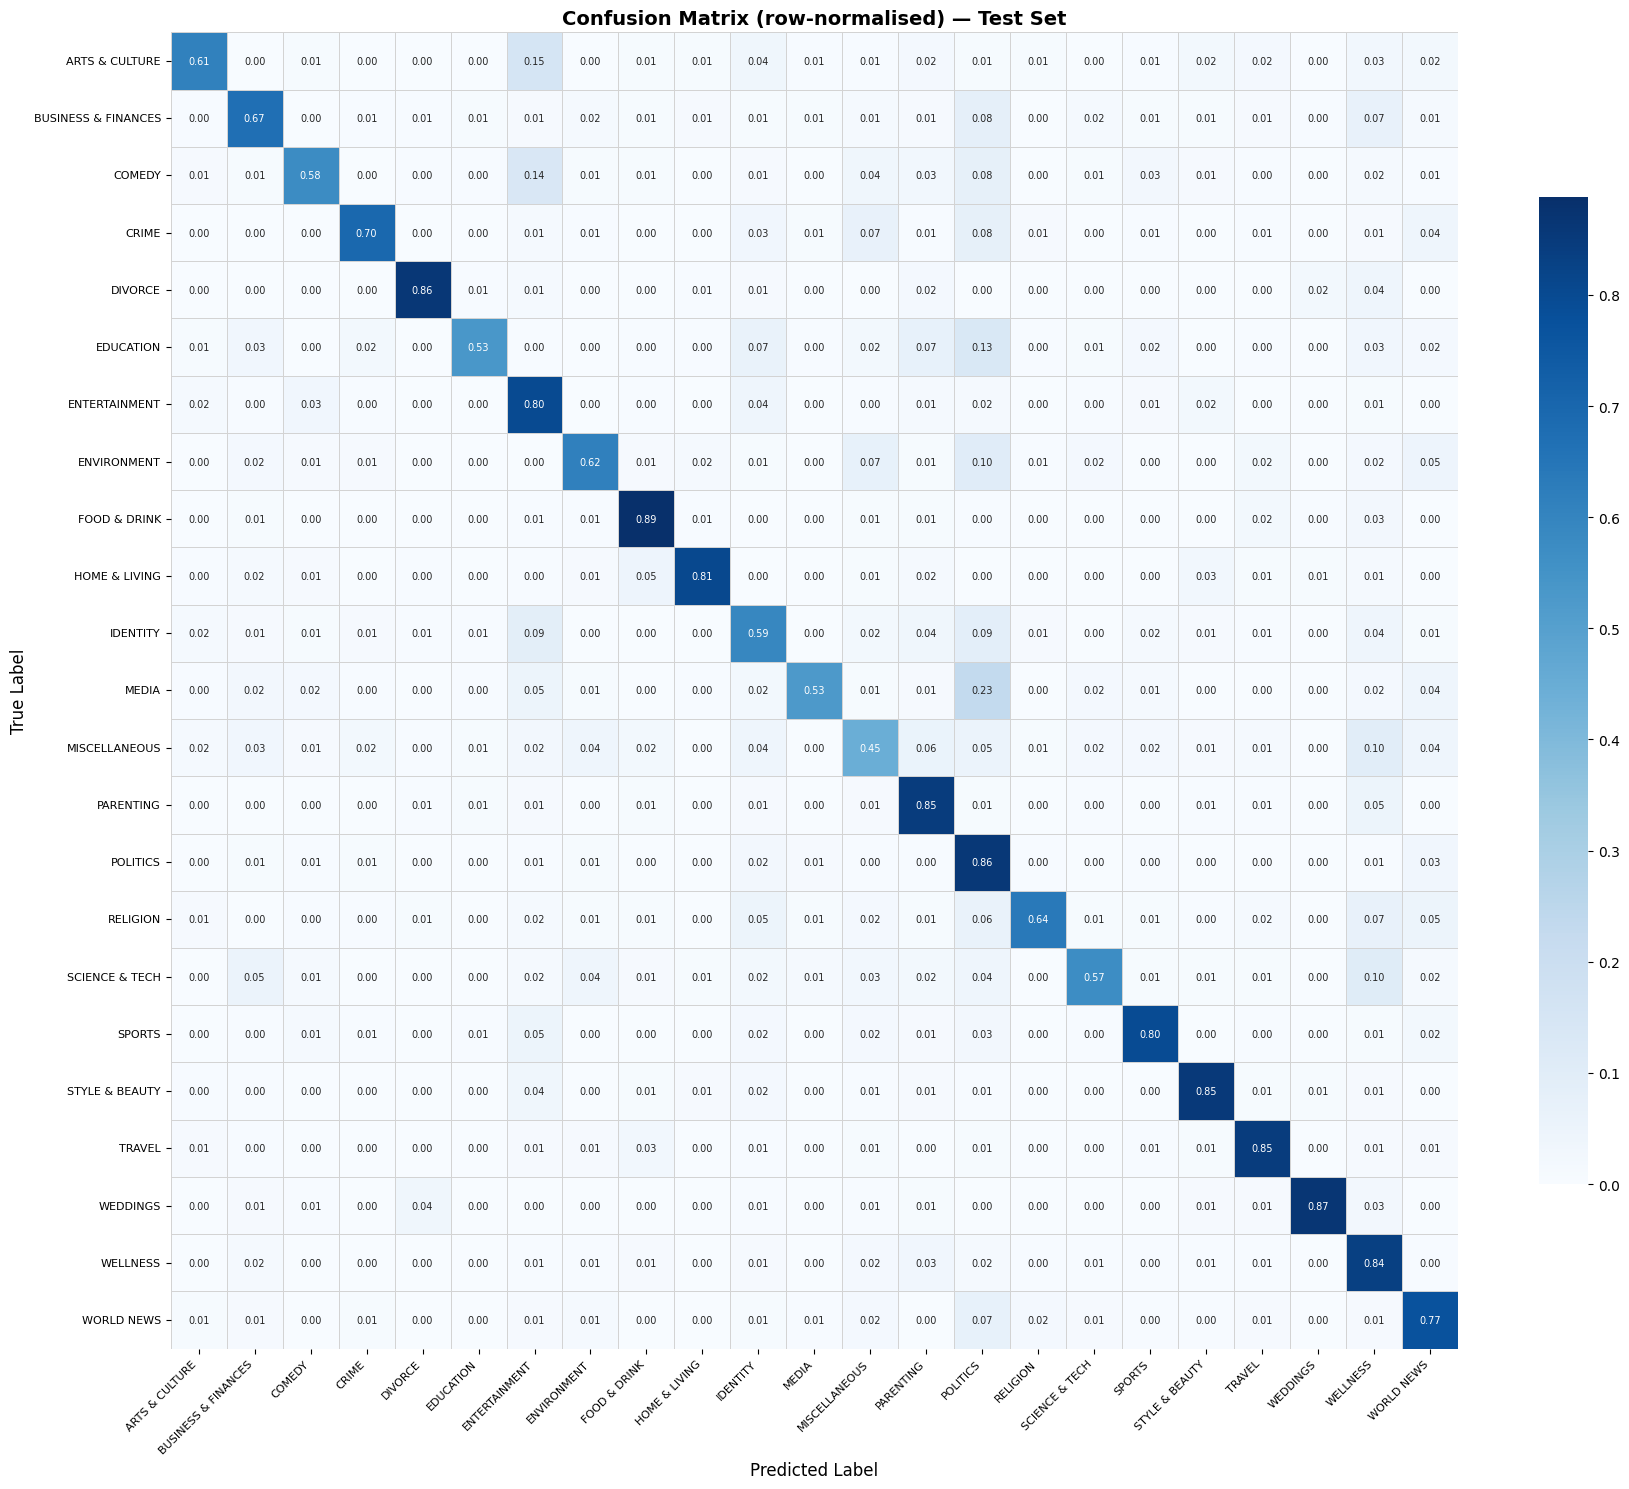

Saved: confusion_matrix.png


In [ ]:
# Row-normalised confusion matrix (shows per-class recall across predicted labels)
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.4,
    linecolor="lightgray",
    ax=ax,
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 7},
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title(
    "Confusion Matrix (row-normalised) — Test Set",
    fontsize=14, fontweight="bold"
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

In [ ]:
# Per-class precision, recall, F1, and support — sorted by F1 descending
report_dict = classification_report(
    test_labels,
    test_preds,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

metrics_df = (
    pd.DataFrame(report_dict)
    .T
    .drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")
    .rename(columns={"precision": "Precision", "recall": "Recall",
                     "f1-score": "F1-Score", "support": "Support"})
    [["Precision", "Recall", "F1-Score", "Support"]]
    .round(4)
    .sort_values("F1-Score", ascending=False)
)
metrics_df["Support"] = metrics_df["Support"].astype(int)

print("Per-class metrics (sorted by F1-Score):")
display(
    metrics_df.style
    .background_gradient(subset=["F1-Score"], cmap="RdYlGn")
    .format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1-Score": "{:.4f}"})
)

Per-class metrics (sorted by F1-Score):


,Precision,Recall,F1-Score,Support
STYLE & BEAUTY,0.8685,0.8537,0.8611,1176
WEDDINGS,0.8564,0.8658,0.8610,365
FOOD & DRINK,0.8202,0.8882,0.8529,832
TRAVEL,0.8548,0.8462,0.8505,988
DIVORCE,0.8310,0.8626,0.8465,342
POLITICS,0.8111,0.8597,0.8347,3272
HOME & LIVING,0.8481,0.8053,0.8261,416
WELLNESS,0.8076,0.8360,0.8216,2451
PARENTING,0.7568,0.8454,0.7986,1255
SPORTS,0.7410,0.7971,0.7680,488


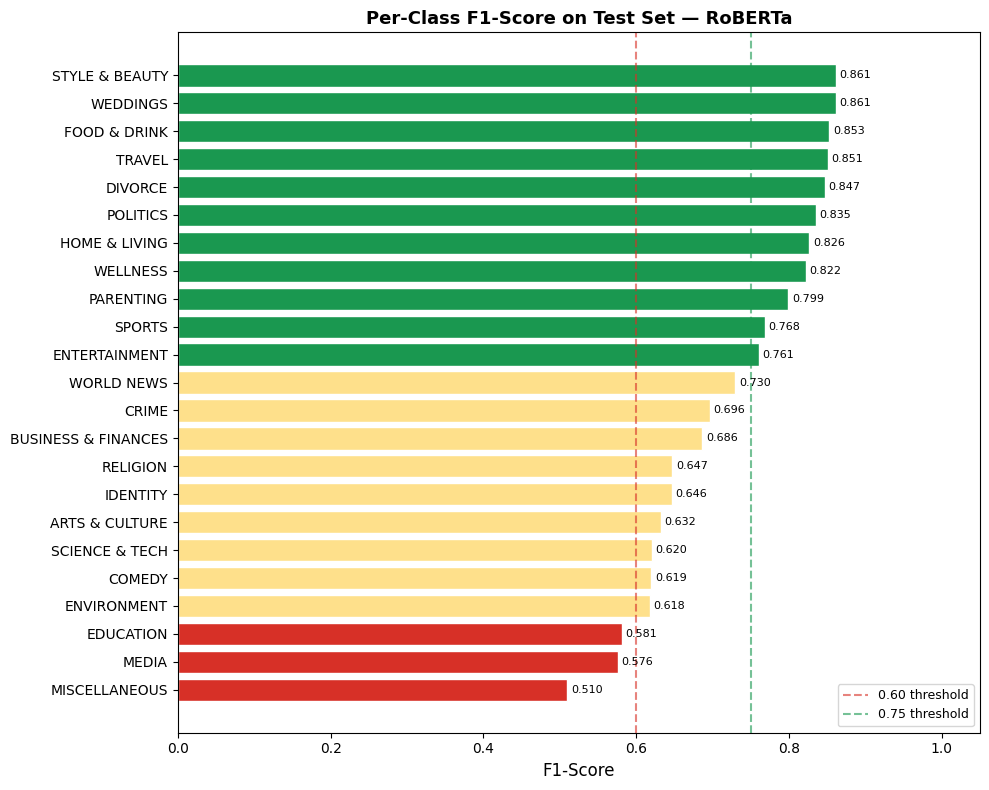

Saved: per_class_f1.png


In [ ]:
# Bar chart of per-class F1 scores for quick visual comparison
f1_sorted = metrics_df["F1-Score"].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d73027" if v < 0.6 else "#fee08b" if v < 0.75 else "#1a9850" for v in f1_sorted]
bars = ax.barh(f1_sorted.index, f1_sorted.values, color=colors, edgecolor="white")
ax.axvline(0.6,  color="#d73027",  linestyle="--", alpha=0.6, label="0.60 threshold")
ax.axvline(0.75, color="#1a9850", linestyle="--", alpha=0.6, label="0.75 threshold")
for bar, val in zip(bars, f1_sorted.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("F1-Score", fontsize=12)
ax.set_title("Per-Class F1-Score on Test Set — RoBERTa", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: per_class_f1.png")

In [ ]:
# ── Final test-set performance summary ────────────────────────
weighted_f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)

print("=" * 58)
print("     FINAL TEST SET PERFORMANCE — RoBERTa (phased)")
print("=" * 58)
print(f"  Accuracy         : {test_acc * 100:6.2f}%")
print(f"  Macro F1-Score   : {test_f1:.4f}")
print(f"  Weighted F1-Score: {weighted_f1:.4f}")
print(f"  Test samples     : {len(test_labels):,}")
print(f"  Number of classes: {num_classes}")
print(f"  Model checkpoint : {CHECKPOINT_PATH}")
print("=" * 58)

print("\nBottom-5 classes by F1-Score (hardest categories):")
print(metrics_df.tail(5)[["F1-Score", "Support"]].to_string())

print("\nTop-5 classes by F1-Score (easiest categories):")
print(metrics_df.head(5)[["F1-Score", "Support"]].to_string())

     FINAL TEST SET PERFORMANCE — RoBERTa (phased)
  Accuracy         :  76.23%
  Macro F1-Score   : 0.7236
  Weighted F1-Score: 0.7585
  Test samples     : 20,036
  Number of classes: 23
  Model checkpoint : best_roberta.pt

Bottom-5 classes by F1-Score (hardest categories):
               F1-Score  Support
COMEDY           0.6194      516
ENVIRONMENT      0.6175      394
EDUCATION        0.5808      215
MEDIA            0.5759      281
MISCELLANEOUS    0.5096      893

Top-5 classes by F1-Score (easiest categories):
                F1-Score  Support
STYLE & BEAUTY    0.8611     1176
WEDDINGS          0.8610      365
FOOD & DRINK      0.8529      832
TRAVEL            0.8505      988
DIVORCE           0.8465      342
